
<h1 align="center"> k-Nearest Neighbors algorithm and hyperparameter tuning </h1>

<pre align="left"> September 10th 2025               <i> Author: Igor Colin </i>               <i> Answers: Mohamed Yassine Khales </i></pre>
* * *

**Goals**
- Implement a **k-Nearest Neighbors (kNN)** classifier **from scratch** in NumPy.
- Use the **Breast Cancer Wisconsin** dataset (scikit-learn).
- Measure and compare **training time** and **inference time** **as a function of the training sample size**.
- Analyze **train/test accuracy** as a function of **k**.
- Visualize and discuss **overfitting vs underfitting** with 2D decision boundaries.

> A 🔧 **Question** indicates that you need to fill **TODO** blocks in the following cell.

> Whenever you encounter a 🧠 **Question**, answer it in the same block.

## 1) Setup

In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

import time

np.random.seed(42)

def describe_split(X_train, X_test, y_train, y_test):
    print(f"Train: X={X_train.shape}, y={y_train.shape} | Test: X={X_test.shape}, y={y_test.shape}")


## 2) Load & preprocess the data

In [2]:

data = load_breast_cancer()
X = data.data.astype(float)
y = data.target.astype(int)
feature_names = data.feature_names
target_names = data.target_names

print("Classes:", list(target_names))
print("Num samples:", X.shape[0], "| Num features:", X.shape[1])

# Standardize (important for kNN)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Train/test split (keep class balance with stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.25, stratify=y, random_state=42
)
describe_split(X_train, X_test, y_train, y_test)

Classes: [np.str_('malignant'), np.str_('benign')]
Num samples: 569 | Num features: 30
Train: X=(426, 30), y=(426,) | Test: X=(143, 30), y=(143,)


🧠 **Question 1.** If we did not standardize features, what might you expect to happen and why?

**Answer 1.** This ensures that all features are on the same scale, which simplifies comparison and makes machine learning algorithms more efficient (they are not biased by some huge numbers because of scale)


## 3) Implement `KNNClassifier` (fill-in-the-blanks)
We follow the `fit`/`predict` API of scikit-learn. For `kNNClassifier`, `fit` simply memorizes the training data.

🔧 **Question 2.** Complete `_predict_one`, so it computes Euclidean distances from argument `x` to all training points, sort, take top-`k`, and majority vote.


In [23]:

class KNNClassifier:
    def __init__(self, n_neighbors=5):
        assert isinstance(n_neighbors, int) and n_neighbors >= 1
        self.k = n_neighbors
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Training = memorize the training data."""
        # TODO: store numpy arrays
        self.X_train = X
        self.y_train = y

    def _predict_one(self, x):
        """Predict the class of a single point by majority vote among k nearest neighbors."""
        
        # TODO 1: distances from x to each sample of X_train
        distances = np.linalg.norm(x-self.X_train, axis=1)
        # TODO 2: sort indices
        idx_sorted = np.argsort(distances)
        # TODO 3: take top-k
        k_idx = idx_sorted[:self.k]
        
        # majority vote
        votes = self.y_train[k_idx]
        return int(np.argmax(np.bincount(votes)))

    def predict(self, X):
        X = np.atleast_2d(X)
        return np.array([self._predict_one(row) for row in X], dtype=int)



## 4) Timing **vs training sample size** (fixed k)
Now we measure **training** and **inference** time as we increase the **training sample size**.

To do so, we use a fixed `k_time` (_e.g._, 11), and for each size `n_train_sub`, create a **stratified** subset of the training set of that size.

🔧 **Question 3.** Complete the `for` loop to record:
  - `fit` time
  - `predict` time

🧠 **Bonus:** Why is using a stratified subset helpful here? (check `StratifiedShuffleSplit` documentation to learn about it) 

**Bonus Answer :** The use of stratified subset helpful allow us to get a subset of X_train, y_train with random elements, so that it will be representant of the whole dataset. (Without that we will have always the same elements + some extra)

In [ ]:
sizes = np.arange(50, 401, 50)

k_time = 11  # fixed k for timing
fit_times = []
pred_times = []

for n_train_sub in sizes:
    # Build a stratified subset of size n_sub from the training set
    strat_shuffler = StratifiedShuffleSplit(n_splits=1, train_size=n_train_sub, random_state=42)
    (idx_sub, _), = strat_shuffler.split(X_train, y_train)
    X_sub = X_train[idx_sub]
    y_sub = y_train[idx_sub]

    knn = KNNClassifier(n_neighbors=k_time)

    # TODO: measure fit time
    t0 = time.time()
    knn.fit(X_sub, y_sub)
    fit_times.append(time.time()-t0)
    # TODO: measure predict time (on X_test)
    t1 = time.time()
    y_hat=knn.predict(X_sub)
    pred_times.append(time.time()-t1)
    

print("sizes:", sizes)
print("fit_times:", fit_times)
print("pred_times:", pred_times)

sizes: [ 50 100 150 200 250 300 350 400]
fit_times: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
pred_times: [0.0010001659393310547, 0.0025336742401123047, 0.0032694339752197266, 0.005520820617675781, 0.0075113773345947266, 0.010013341903686523, 0.011520624160766602, 0.01533365249633789]


Check your implementation graphically using the following code.

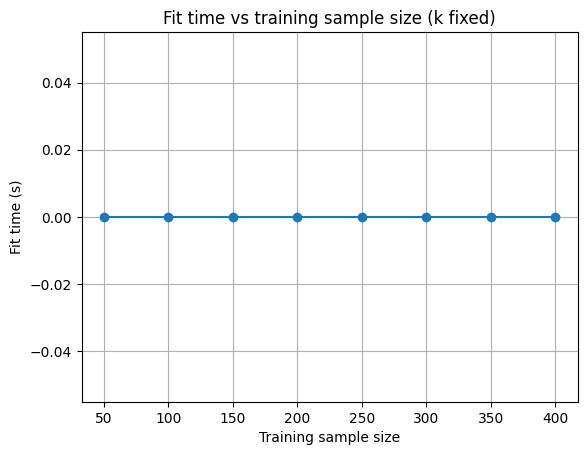

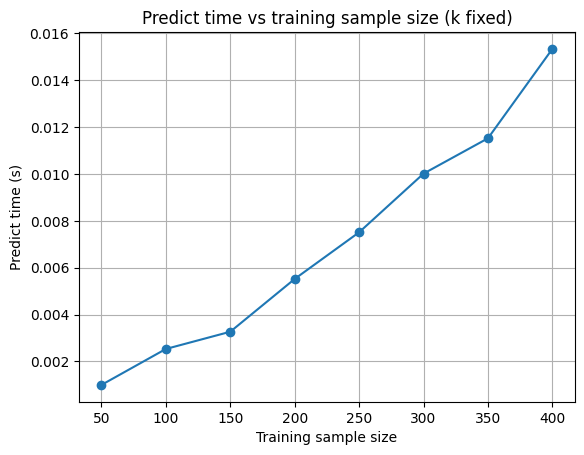

In [18]:

plt.figure()
plt.plot(sizes, fit_times, marker="o")
plt.xlabel("Training sample size")
plt.ylabel("Fit time (s)")
plt.title("Fit time vs training sample size (k fixed)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(sizes, pred_times, marker="o")
plt.xlabel("Training sample size")
plt.ylabel("Predict time (s)")
plt.title("Predict time vs training sample size (k fixed)")
plt.grid(True)
plt.show()

🧠 **Question 4.** Describe and explain the relation between inference time and sample size.

- We see that the fit time is null, that's because the kNNClassifier doesn't have a "training phase" like neural networks. We just stock the training data in order to use it for the prediction.

- We see that the predict time increases with the sample size, as shown in the figure before.


## 5) Train/Test accuracy vs k

Depending on the value of `k`, our classifier may produce different predictions. One way to select a value for the number of neighbors `k` is to analyze the accuracy on the test set.

🔧 **Question 5.** Complete the `for` loop below so that we store the train/test accuracy for several values of `k`

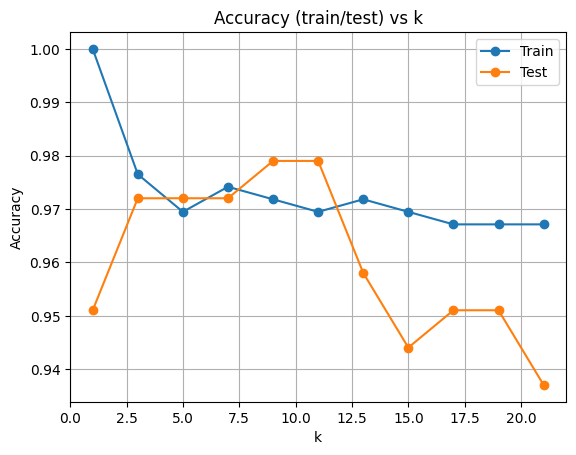

In [38]:
def accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()
    
ks = np.arange(1, 22, 2)
train_scores = []
test_scores = []

for k in ks:
    knn = KNNClassifier(n_neighbors=int(k)) # I have to do int(k) because otherwise i get an assertion error (maybe because int != np.int64)
    # TODO: fit on full training set
    knn.fit(X_train, y_train)
    # TODO: make predictions
    y_tr = knn.predict(X_train)
    y_te = knn.predict(X_test)
    train_scores.append(accuracy(y_train, y_tr))
    test_scores.append(accuracy(y_test, y_te))

plt.figure()
plt.plot(ks, train_scores, marker="o", label="Train")
plt.plot(ks, test_scores, marker="o", label="Test")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy (train/test) vs k")
plt.legend()
plt.grid(True)
plt.show()


🧠 **Question 6.** Discuss the evolution of the train accuracy w.r.t. `k`. Same with the test accuracy. Which value should we pick for `k`?

**Answer 6.** We see here that the training accuracy drops significantly fast. The best model here is for $k=1$.

For $k=1$ however, the testing data have one of the worst accuracies. This is a case of overfiting (model excelent on training data, but not good on new datas)

For the testing data however, we see that the accuracy grows until $k=11$ and then drops significantly (and grows a little bit before dropping again, but the accuracy is very low compared to before). In this case, the ideal values of $k$ are : $k=11$ or $k=9$


## 7) Decision boundaries (2D) and overfitting

Another way to notice overfitting is to look at decision boundaries, in particular their smoothness.

🔧 **Question 7.** Complete the `plot_decision_boundary_2d` function so that it fits a 2D projection of the dataset and plot the decision boundary for 3 values of `k` (typically 1, 21 and the value you have picked in **Q6**).


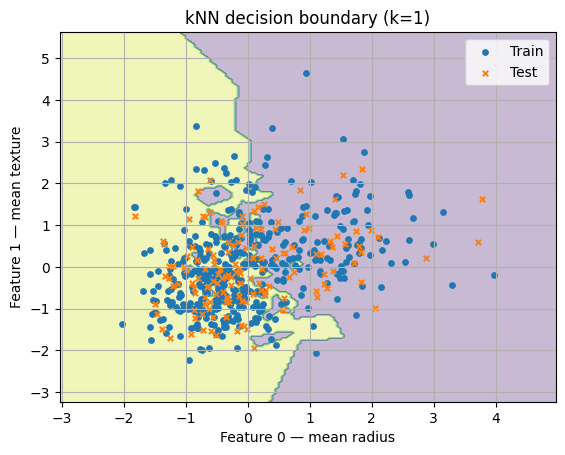

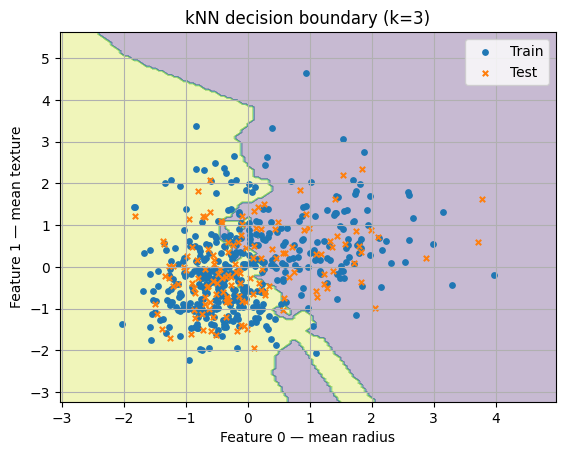

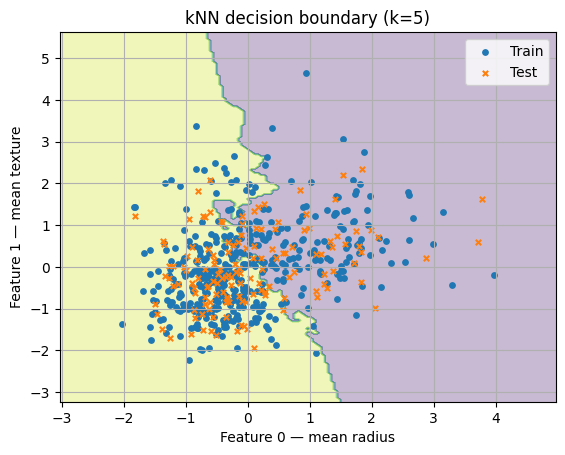

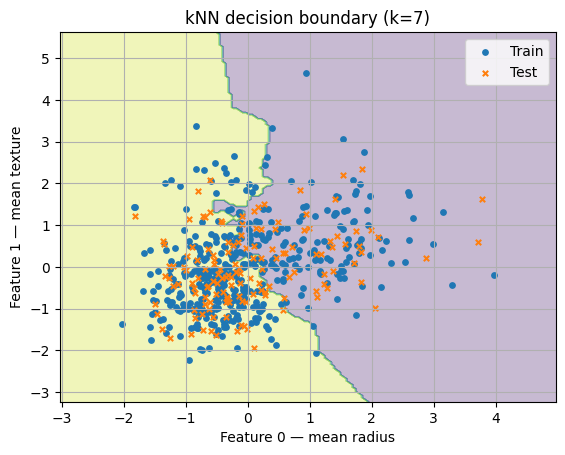

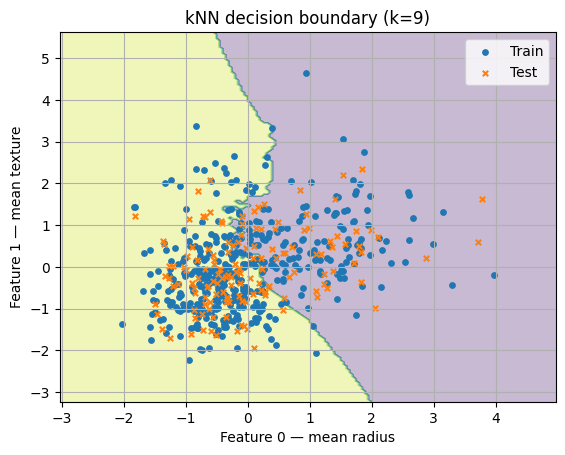

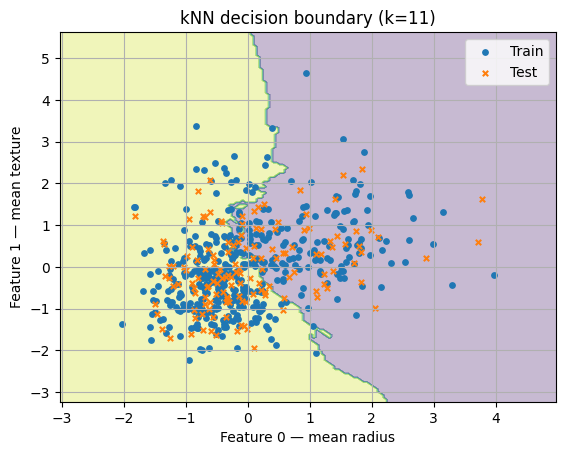

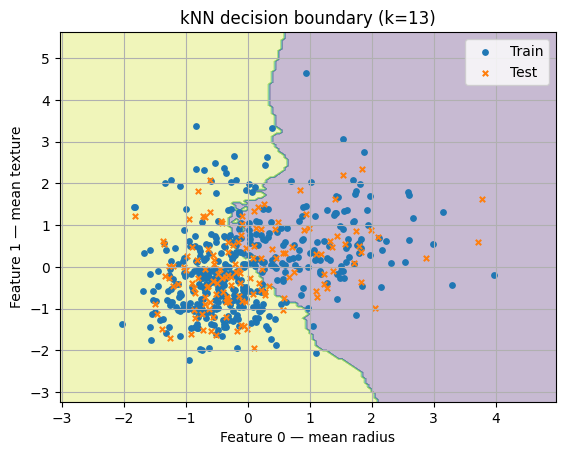

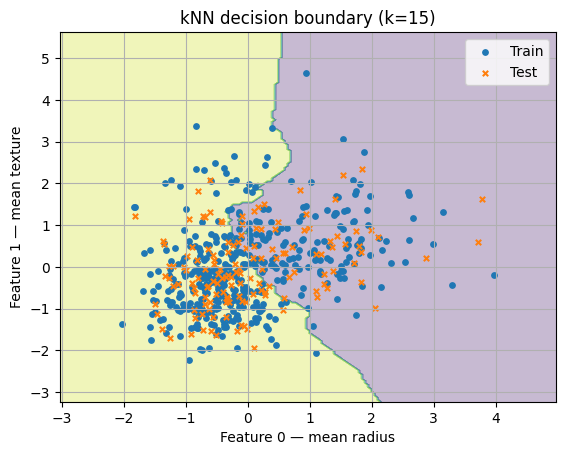

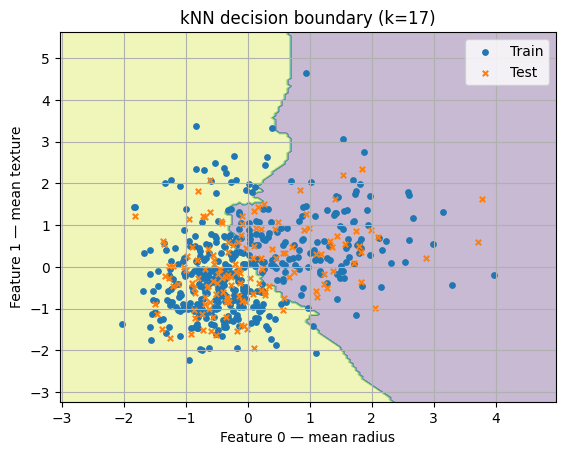

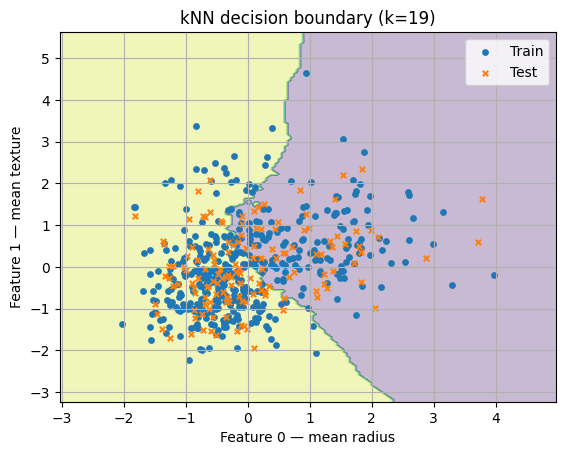

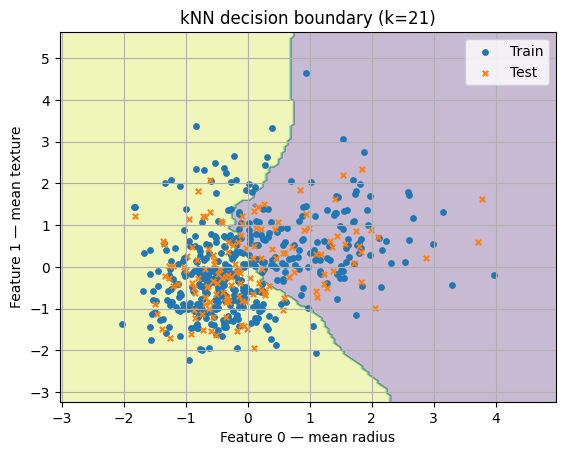

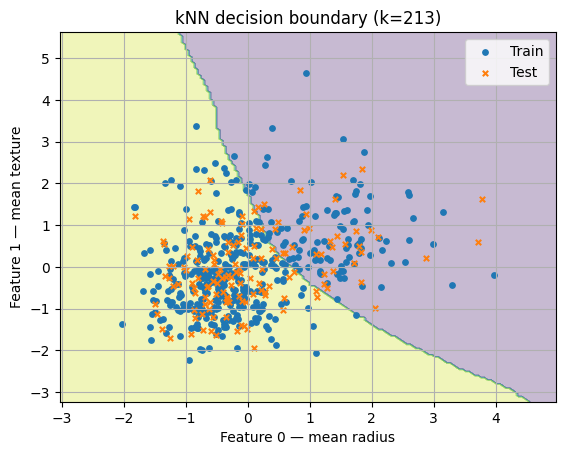

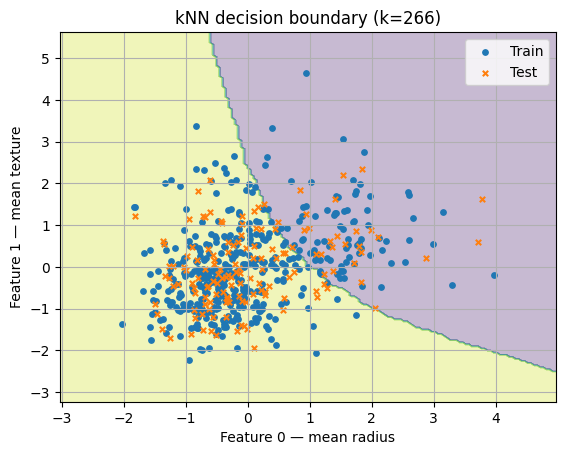

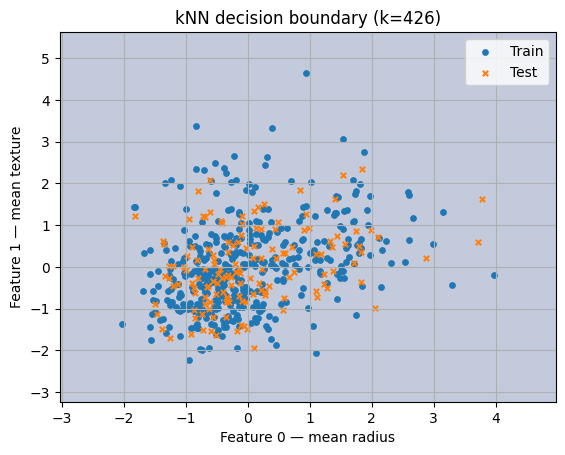

In [46]:

def plot_decision_boundary_2d(X_train, y_train, X_test, y_test, feature_idx=(0,1), k=5, h=0.05):
    i, j = feature_idx
    Xtr = X_train[:, [i, j]]
    Xte = X_test[:, [i, j]]

    knn = KNNClassifier(n_neighbors=k)
    # TODO: fit on 2D projected training data
    knn.fit(Xtr, y_train)

    x_min, x_max = Xtr[:,0].min() - 1.0, Xtr[:,0].max() + 1.0
    y_min, y_max = Xtr[:,1].min() - 1.0, Xtr[:,1].max() + 1.0
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = knn.predict(grid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(Xtr[:,0], Xtr[:,1], s=15, label="Train")
    plt.scatter(Xte[:,0], Xte[:,1], s=15, marker="x", label="Test")
    plt.xlabel(f"Feature {i} — {feature_names[i]}")
    plt.ylabel(f"Feature {j} — {feature_names[j]}")
    plt.title(f"kNN decision boundary (k={k})")
    plt.legend()
    plt.grid(True)
    plt.show()

# TODO: plot the decision boundary for various values of k
for k in ks:
    plot_decision_boundary_2d(X_train, y_train, X_test, y_test, feature_idx=(0,1), k = int(k))

plot_decision_boundary_2d(X_train, y_train, X_test, y_test, feature_idx=(0,1), k = len(X_train)//2)
plot_decision_boundary_2d(X_train, y_train, X_test, y_test, feature_idx=(0,1), k = 5*len(X_train)//8)
plot_decision_boundary_2d(X_train, y_train, X_test, y_test, feature_idx=(0,1), k = len(X_train))

🧠 **Question 8.** Comment the shape of the decision boundary for the different values of `k`.

We remark that for small $k$ values the decision boundaries are very irregular, not smooth.

As long as $k$ grows, the decision boundaries gets smoother and smoother until it becomes uniform (``k=len(X_train)``). We have in this case only one decision boundary. (Because for every point are just labelled by the majority of labels in the whole training dataset -> the output will always be the same)